## Task 2 — sentiment by call type

Gemini scores each call from the customer's own lines (ignoring the agent's
politeness, which otherwise inflates everything). Besides an overall score I ask
for the opening/closing sentiment and the worst single moment, which gives me a
start→end swing and a "frustration peak" to look at separately from the average.

Loads the labeled dataset from notebook 1 — no re-loading transcripts.

In [9]:
import pandas as pd
df = pd.read_csv("output/labeled.csv")   # from notebook 1
print(len(df), "transcripts")

99 transcripts


In [10]:
import os, enum
from google import genai
from google.genai import types
from pydantic import BaseModel

def load_env(path=".env"):
    """Read KEY=VALUE lines from a .env file into environment variables."""
    for line in open(path):
        line = line.strip()
        if line and not line.startswith("#") and "=" in line:
            k, v = line.split("=", 1)
            os.environ.setdefault(k.strip(), v.strip().strip("\"'"))
load_env()

MODEL = "gemini-3.1-flash-lite"
client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])

def ask(prompt, schema):
    """Send one prompt to Gemini and return the reply parsed into the given Pydantic schema."""
    resp = client.models.generate_content(
        model=MODEL, contents=prompt,
        config=types.GenerateContentConfig(
            response_mime_type="application/json",
            response_schema=schema,
            # small thinking budget: a little reasoning for ambiguous calls without
            # eating much of the token budget (0 = off, -1 = dynamic/unbounded)
            thinking_config=types.ThinkingConfig(thinking_budget=512),
            max_output_tokens=65536))
    return resp.parsed

def run_batch(items, schema, instruction):
    """Send all (id, text) items to Gemini in one call and return {id: parsed record}."""
    block = "\n\n".join(f"### ID: {cid}\n{txt}" for cid, txt in items)
    return {r.id: r for r in ask(f"{instruction}\nItems:\n{block}", list[schema])}

In [11]:
class Label(str, enum.Enum):
    POSITIVE = "positive"
    NEUTRAL  = "neutral"
    NEGATIVE = "negative"

class Sentiment(BaseModel):
    id: str
    label: Label
    score: float
    opening: float
    closing: float
    low_point: float
    reason: str

SENTIMENT_PROMPT = (
    "Rate the customer's sentiment in each call from their own words (ignore agent "
    "politeness). Give the label, an overall score, the opening and closing sentiment, "
    "the most negative moment (low_point), and a short reason. Scores are -1..1. Keep the ID.")

def add_sentiment(df):
    """Score each call's customer sentiment via Gemini and merge the scores onto df."""
    recs = run_batch(list(zip(df.call_id, df.voice_text)), Sentiment, SENTIMENT_PROMPT)
    scored = pd.DataFrame([{"call_id": r.id, "sentiment": r.label.value,
                            "sentiment_score": round(r.score, 3),
                            "frustration_peak": round(r.low_point, 3),   # worst moment
                            "delta": round(r.closing - r.opening, 3),    # start -> end swing
                            "sentiment_reason": r.reason[:80]} for r in recs.values()])
    return df.merge(scored, on="call_id", how="left")

In [12]:
df = add_sentiment(df)
df.to_csv("output/scored.csv", index=False)    # + sentiment, for notebook 3
df[["call_id", "call_type", "sentiment", "sentiment_score",
    "frustration_peak", "delta", "sentiment_reason"]].head(8)

,call_id,call_type,sentiment,sentiment_score,frustration_peak,delta,sentiment_reason
0,EXT-001,external,neutral,0.1,-0.4,0.6,Customer is concerned about the budget but rea...
1,EXT-002,external,positive,0.6,0.0,0.9,Initial skepticism about ROI transitioned into...
2,EXT-003,external,neutral,-0.1,-0.5,0.7,Mixed adoption concerns are offset by optimism...
3,EXT-004,external,negative,-0.6,-0.8,0.2,Ultimatum regarding missing compliance feature...
4,EXT-005,external,neutral,0.0,-0.4,0.6,Budget frustration and mixed experiences tempe...
5,EXT-006,external,neutral,0.1,-0.5,0.9,Onboarding struggles are addressed with a prod...
6,EXT-007,external,positive,0.4,-0.4,1.1,Low confidence in the past quarter was overcom...
7,EXT-008,external,neutral,0.0,-0.3,0.5,Balancing powerful features against steep lear...


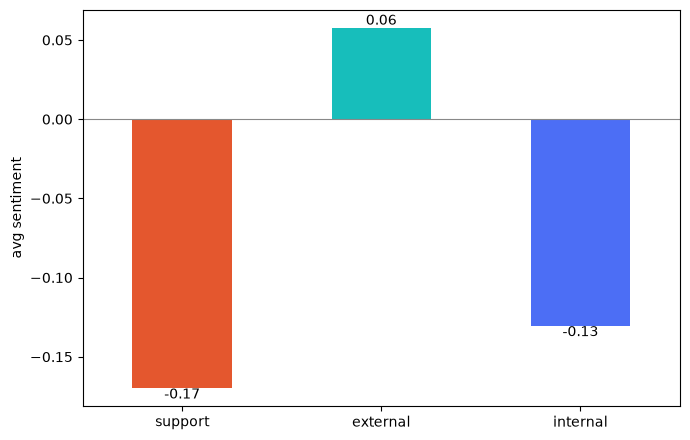

In [13]:
%matplotlib inline
import matplotlib.pyplot as plt
colors = {"support": "#E4572E", "external": "#17BEBB", "internal": "#4C6EF5"}
order = ["support", "external", "internal"]
means = df.groupby("call_type").sentiment_score.mean().reindex(order)
ax = means.plot(kind="bar", figsize=(7, 4.5), color=[colors[c] for c in order], rot=0)
ax.axhline(0, color="#888", lw=0.8); ax.set_ylabel("avg sentiment"); ax.set_xlabel("")
for i, v in enumerate(means):
    ax.text(i, v, f"{v:.2f}", ha="center", va="bottom" if v >= 0 else "top")
plt.tight_layout()

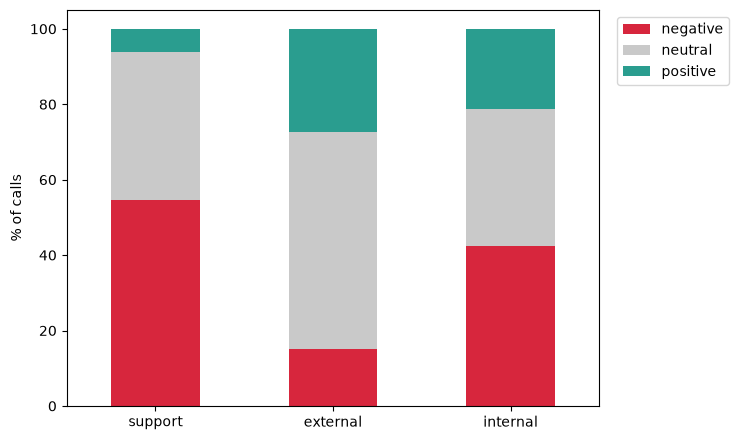

In [14]:
mix = (df.groupby(["call_type", "sentiment"]).size().unstack(fill_value=0)
         .reindex(index=order).reindex(columns=["negative", "neutral", "positive"], fill_value=0))
(mix.div(mix.sum(axis=1), axis=0) * 100).plot(
    kind="bar", stacked=True, figsize=(7.5, 4.5), rot=0,
    color={"negative": "#D7263D", "neutral": "#C9C9C9", "positive": "#2A9D8F"})
plt.ylabel("% of calls"); plt.xlabel(""); plt.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

Average sentiment hides the bad moments — here's the mean frustration peak instead.

In [15]:
df.groupby("call_type").frustration_peak.mean().round(3)

call_type
external   -0.430
internal   -0.458
support    -0.482
Name: frustration_peak, dtype: float64

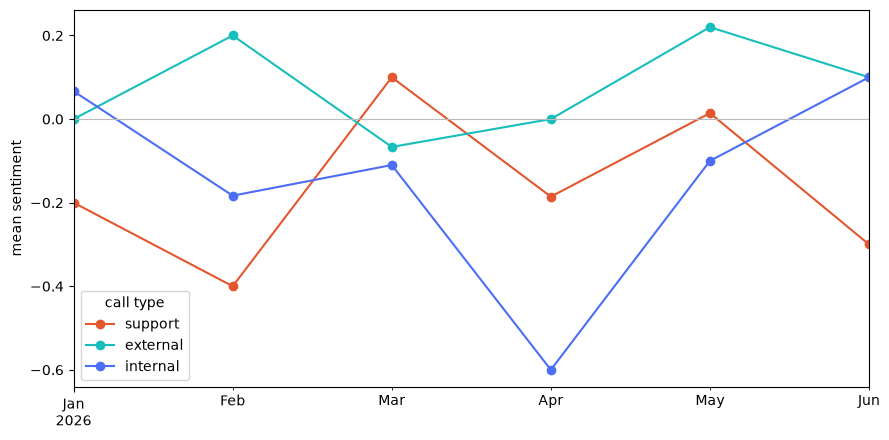

In [16]:
d = df.assign(month=pd.to_datetime(df.date).dt.to_period("M").dt.to_timestamp())
piv = d.groupby(["month", "call_type"]).sentiment_score.mean().unstack().reindex(columns=order)
piv.plot(figsize=(9, 4.5), marker="o", color=[colors[c] for c in piv.columns])
plt.axhline(0, color="#bbb", lw=0.8); plt.ylabel("mean sentiment"); plt.xlabel("")
plt.legend(title="call type"); plt.tight_layout()

What stands out:

External calls score highest, support lowest, internal is the swingiest and holds
basically all the negative calls. That tracks — renewal/QBR chats are friendly by
nature (which is also why a happy-looking external call can still be a churn risk;
see Task 3), and people only call support when something's broken.

The frustration-peak numbers are the more useful signal: support and internal
incident calls have sharp low points that the averages smooth over. If we ever put
this on a dashboard I'd surface the peak, not just the mean. And the negativity
that lives in internal calls (postmortems, escalations) is stuff customers never
hear directly — good that it surfaces internally, but worth watching for on-call
burnout.